# Models evaluator notebook  

## Load and prepare data

In [1]:
import json
import os
import pandas as pd

In [15]:
# Read all JSON files from the specified directory
outputs_path = '/Users/sofi/Desktop/collectiveai/projects/AymurAI/'
json_files = [f for f in os.listdir(outputs_path) if f.endswith('.json')]
json_files

['anonymization_paragraph-all.json',
 'anonymization_document_paragraph-doc06.json',
 'anonymization_document-doc06.json',
 'anonymization_document-all.json',
 'anonymization_document_paragraph-all.json',
 'anonymization_paragraph-doc06.json']

### Exploratory 

In [461]:
doc_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_document-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_document.json')
])
doc_df.head(2)


,id,created_at,updated_at,name
0,f8761c56b39b5a6387367266f7c67bae,2025-08-12 20:39:26-03:00,NaT,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,4da9843514255b96b1090ad5dd685144,2025-08-24 18:44:21-03:00,NaT,document-06.docx


In [462]:
doc_para_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_document_paragraph-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_document_paragraph.json')])
doc_para_df.head

<bound method NDFrame.head of                                   id                       document_id  \
0   f8e779753ed54f62b71cb0033d2dceff  f8761c56b39b5a6387367266f7c67bae   
1   f98629e4b8bf4f09801c1563ae0cdcec  f8761c56b39b5a6387367266f7c67bae   
2   087aca489e47468fa4fce332248c3dd7  f8761c56b39b5a6387367266f7c67bae   
3   e51935f992bf4c55a3ce541b3f96787a  f8761c56b39b5a6387367266f7c67bae   
4   e8ce401964d0415db128c1eedbf1a54e  f8761c56b39b5a6387367266f7c67bae   
..                               ...                               ...   
95  60089cc2d5954e4c807bfa8feea56e4a  da0791b5cfb7552697d151574d2e7a09   
96  87422dbccbc24861937009924a18e2aa  da0791b5cfb7552697d151574d2e7a09   
97  15a37f44f66a4c5d920a12c355bf7dd0  da0791b5cfb7552697d151574d2e7a09   
98  38e1d7f168ab46fa9dd269f46c519f4b  da0791b5cfb7552697d151574d2e7a09   
99  bb81b6061c3d4a89a1d94d5ef6956ead  da0791b5cfb7552697d151574d2e7a09   

                        paragraph_id  order  
0   59dc7264d5845c30b01d3de2de4df1f

In [463]:
merged_df = pd.merge(
    doc_para_df,
    doc_df[['id', 'created_at', 'name']],
    left_on='document_id',
    right_on='id',
    how='left'
)
merged_df = merged_df.rename(columns={'id_x': 'par_id'}).drop(columns=['id_y'])
merged_df.head(2)

,par_id,document_id,paragraph_id,order,created_at,name
0,f8e779753ed54f62b71cb0033d2dceff,f8761c56b39b5a6387367266f7c67bae,59dc7264d5845c30b01d3de2de4df1fa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx


In [464]:
para_df = pd.concat([
    pd.read_json(outputs_path + 'anonymization_paragraph-doc06.json'),
    pd.read_json(outputs_path + 'anonymization_paragraph.json')])
para_df.head(3)

,text,prediction,validation,id,created_at,updated_at
0,Acusado: Ramiro Marrón DNI 34.555.666.,"[{""start"": 1, ""end"": 3, ""label"": ""PER"", ""text""...",null,735e0ac6ee97548aab5402e61fc6487c,2025-07-22 02:20:28-03:00,NaT
1,1983-2023. 40 Años de Democracia,[],[],59dc7264d5845c30b01d3de2de4df1fa,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00


In [465]:
df = pd.merge(
    para_df,
    merged_df,
    left_on='id',
    right_on='paragraph_id',
    how='left'
)
#merged_df = merged_df.rename(columns={'id_x': 'id'}).drop(columns=['id_y'])
df.head(10)

,text,prediction,validation,id,created_at_x,updated_at,par_id,document_id,paragraph_id,order,created_at_y,name
0,Acusado: Ramiro Marrón DNI 34.555.666.,"[{""start"": 1, ""end"": 3, ""label"": ""PER"", ""text""...",null,735e0ac6ee97548aab5402e61fc6487c,2025-07-22 02:20:28-03:00,NaT,NaN,NaN,NaN,NaN,NaT,NaN
1,1983-2023. 40 Años de Democracia,[],[],59dc7264d5845c30b01d3de2de4df1fa,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,f8e779753ed54f62b71cb0033d2dceff,f8761c56b39b5a6387367266f7c67bae,59dc7264d5845c30b01d3de2de4df1fa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
3,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,5e6e2c92735c4d52a54cd9aa6365d00e,06918bd1795951b686d880d48f757e6b,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
4,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
5,"TELIAS, PABLO MARTIN SOBRE 149 BIS - AMENAZAS","[{""start"": 0, ""end"": 3, ""label"": ""PER"", ""text""...","[{""text"": ""TELIAS, PABLO MARTIN"", ""start_char""...",a728442cf12a51ddb2d4b42c1d97b002,2025-08-12 20:37:33-03:00,2025-08-12 20:39:26-03:00,087aca489e47468fa4fce332248c3dd7,f8761c56b39b5a6387367266f7c67bae,a728442cf12a51ddb2d4b42c1d97b002,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
6,Número: IPP 1234/2023-0,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""IPP 1234/2023-0"", ""start_char"": 8, ...",a76fa4cb055c5abe9116330762c71b92,2025-08-12 20:37:33-03:00,2025-08-12 20:39:26-03:00,e51935f992bf4c55a3ce541b3f96787a,f8761c56b39b5a6387367266f7c67bae,a76fa4cb055c5abe9116330762c71b92,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
7,Actuación Nro: 22233/2023,"[{""start"": 2, ""end"": 3, ""label"": ""NUM_ACTUACIO...","[{""text"": ""22233/2023"", ""start_char"": 15, ""end...",d12b16a0c8e354109c5087b1287a35aa,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,90d4dfda98e74450a3fe91f3b541a318,f8761c56b39b5a6387367266f7c67bae,d12b16a0c8e354109c5087b1287a35aa,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
8,CUIJ: IPP J-01-00001234-6/2023-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00001234-6/2023-0"", ""start...",76b4b01704975fc2a40f5bfa41890242,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,e8ce401964d0415db128c1eedbf1a54e,f8761c56b39b5a6387367266f7c67bae,76b4b01704975fc2a40f5bfa41890242,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
9,AUDIENCIA CON LA VÍCTIMA,[],[],9ce24ca96fb3541c84433f5740594076,2025-08-12 20:37:38-03:00,2025-08-12 20:39:26-03:00,4dd451ea78fc4e059e3ee2eb9e6c9a7d,f8761c56b39b5a6387367266f7c67bae,9ce24ca96fb3541c84433f5740594076,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx


### Generalized load for multiple json files:

In [16]:
para_files = [f for f in json_files if f.startswith('anonymization_paragraph')]
para_df = pd.concat([pd.read_json(outputs_path + fname) for fname in para_files], ignore_index=True)

doc_files = [f for f in json_files if f.startswith('anonymization_document') and not 'paragraph' in f]
doc_df = pd.concat([pd.read_json(outputs_path + fname) for fname in doc_files], ignore_index=True)

doc_para_files = [f for f in json_files if f.startswith('anonymization_document_paragraph')]
doc_para_df = pd.concat([pd.read_json(outputs_path + fname) for fname in doc_para_files], ignore_index=True)

doc_df = doc_df.copy()
doc_para_df = doc_para_df.copy()
doc_df['id'] = doc_df['id'].astype(str)
doc_para_df['document_id'] = doc_para_df['document_id'].astype(str)


merged_df = pd.merge(
    doc_para_df,
    doc_df[['id', 'created_at', 'name']],
    left_on='document_id',
    right_on='id',
    how='left'
).rename(columns={'id_x': 'id'}).drop(columns=['id_y'])

df = pd.merge(
    para_df,
    merged_df,
    left_on='id',
    right_on='paragraph_id',
    how='left'
)

df.head(5)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,f98629e4b8bf4f09801c1563ae0cdcec,f8761c56b39b5a6387367266f7c67bae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-12 20:39:26-03:00,5188_57_20_01_2023_149bis CAUSA 4671_2023.docx
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5e6e2c92735c4d52a54cd9aa6365d00e,06918bd1795951b686d880d48f757e6b,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-08 19:40:46-03:00,7719_84_25_04_2025_128 CAUSA 108848_2024.docx
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
3,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx
4,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx


In [55]:
eval(df.validation.unique()[20])

[{'text': 'Telefónica Móviles Argentina SA',
  'start_char': 48,
  'end_char': 79,
  'attrs': {'aymurai_label': 'TEXTO_ANONIMIZAR',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'Telefónica Móviles Argentina SA',
   'aymurai_alt_start_char': 48,
   'aymurai_alt_end_char': 79,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.7135604172945023}},
 {'text': 'Celeste Sol Sakowicz',
  'start_char': 165,
  'end_char': 185,
  'attrs': {'aymurai_label': 'PER',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'Celeste Sol Sakowicz',
   'aymurai_alt_start_char': 165,
   'aymurai_alt_end_char': 185,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9736723303794861}},
 {'text': '34.711.322',
  'start_char': 191,
  'end_char': 201,
  'attrs': {'aymurai_label': 'DNI',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': '34.711.322',
   'aymurai_alt_start_char': 191,
   'aymurai_alt_end_char': 201,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9999989271163

In [474]:
def metrics_for_label(df, target = 'text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        try:
            val = eval(df.validation.iloc[i])[0]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[0]
        except:
            pred = []
        
        if target == 'text':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            pred_set = set((text_pred,))
            val_set = set((text_val,))

        elif target == 'label':
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((label_pred,))
            val_set = set((label_val,))

        elif target == 'both':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((text_pred, label_pred))
            val_set = set((text_val, label_val))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        if len(pred_set)>0 or len(val_set)>0: 
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / ( tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}


In [476]:
# TN es importante pero no cuenta en precision/recall/f1

### Test

In [48]:
from collections import defaultdict

def metrics_per_entity_by_span(df):
    # acumula TP/FP/FN por entidad (label)
    counts = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for i in range(len(df)):
        # cada celda puede ser una lista de dicts; si falla, lista vacía
        try:
            val_list = eval(df.validation.iloc[i])
        except:
            val_list = []
        try:
            pred_list = eval(df.prediction.iloc[i])
        except:
            pred_list = []
            
        # sets de spans por label: {(start, end), ...}
        val_spans = defaultdict(set)
        pred_spans = defaultdict(set)

        # VALIDATION (val)
        for v in (val_list or []):
            if not isinstance(v, dict):
                continue
            lab = (v.get('attrs', {}).get('aymurai_label', None)) or v.get('label', None)
            s = v.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = v.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                val_spans[lab].add((int(s), int(e)))
                #print('validation:')
                #print(lab, s, e)
        print('val_spans: ', val_spans)

        # PREDICTIONS
        for p in (pred_list or []):
            if not isinstance(p, dict):
                continue
            lab = (p.get('attrs', {}).get('aymurai_label', None)) or p.get('label', None)
            s = p.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = p.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                pred_spans[lab].add((int(s), int(e)))
                #print('prediction:')
                #print(lab, s, e)
        print('pred_spans: ', pred_spans)
        # actualizar TP/FP/FN por label en esta fila
        for lab in set(list(val_spans.keys()) + list(pred_spans.keys())):
            vs = val_spans.get(lab, set())
            ps = pred_spans.get(lab, set())
            tp = len(ps & vs)
            fp = len(ps - vs)
            fn = len(vs - ps)
            counts[lab]['tp'] += tp
            counts[lab]['fp'] += fp
            counts[lab]['fn'] += fn

    # calcular métricas por label + micro/macro
    out = {'per_label': {}, 'micro': {}, 'macro': {}}
    micro_tp = micro_fp = micro_fn = 0

    for lab, c in counts.items():
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn  # cantidad de entidades de referencia (validation) para ese label
        out['per_label'][lab] = {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}
        micro_tp += tp; micro_fp += fp; micro_fn += fn

    # micro
    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0
    out['micro'] = {'precision': micro_p, 'recall': micro_r, 'f1': micro_f, 'support': micro_tp + micro_fn}

    # macro (promedio simple entre labels presentes)
    if out['per_label']:
        L = len(out['per_label'])
        macro_p = sum(m['precision'] for m in out['per_label'].values()) / L
        macro_r = sum(m['recall']    for m in out['per_label'].values()) / L
        macro_f = sum(m['f1']        for m in out['per_label'].values()) / L
    else:
        macro_p = macro_r = macro_f = 0.0
    out['macro'] = {'precision': macro_p, 'recall': macro_r, 'f1': macro_f}

    return out


In [51]:
out

{'per_label': {'DIRECCION': {'precision': 0.9846153846153847,
   'recall': 0.8767123287671232,
   'f1': 0.927536231884058,
   'support': 73},
  'CORREO_ELECTRÓNICO': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 10},
  'TEXTO_ANONIMIZAR': {'precision': 0.47619047619047616,
   'recall': 1.0,
   'f1': 0.6451612903225806,
   'support': 10},
  'TELEFONO': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 19},
  'NUM_ACTUACION': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 10},
  'NUM_EXPEDIENTE': {'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0,
   'support': 26},
  'PER': {'precision': 0.9708333333333333,
   'recall': 0.8291814946619217,
   'f1': 0.8944337811900192,
   'support': 281},
  'CUIJ': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 8},
  'DNI': {'precision': 0.972972972972973,
   'recall': 1.0,
   'f1': 0.9863013698630138,
   'support': 36},
  'FECHA': {'precision': 0.9716312056737588,
   'recall': 0.9716312056737588,
   'f1': 0.9716

In [50]:
vs = {(312, 323), (400, 412), (55, 66), (238, 250)}
ps = {(312, 323), (423, 412), (55, 66), (238, 250)}
print(vs & ps, vs - ps, ps - vs)

{(312, 323), (55, 66), (238, 250)} {(400, 412)} {(423, 412)}


In [49]:
metrics_per_entity_by_span(df_main)

val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {})
pred_spans:  defaultdict(<class 'set'>, {})
val_spans:  defaultdict(<class 'set'>, {'DIRECCION': {(21, 41)}, 'CORREO_ELECTRÓNICO': {(44, 69)}, 'TELEFONO': {(72, 84)}, 'TEXTO_ANONIMIZAR': {(88, 95)}})
pred_spans:  defaultdict(<class 'set'>, {'DIRECCION': {(21, 41)}, 'TEXTO_ANONIMIZAR': {(88, 95), (44, 69)}, 'TELEFONO': {(72, 84)}})
val_spans:  defaultdict(<class 'set'>, {'DIRECCION': {(21, 41)}, 'CORREO_ELECTRÓNICO': {(44, 69)}, 'TELEFONO': {(72, 84)}, 'TEXTO_ANONIMIZAR': {(88, 95)}})
pred_spans:  defaultdict(<class '

{'per_label': {'DIRECCION': {'precision': 0.9846153846153847,
   'recall': 0.8767123287671232,
   'f1': 0.927536231884058,
   'support': 73},
  'CORREO_ELECTRÓNICO': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 10},
  'TEXTO_ANONIMIZAR': {'precision': 0.47619047619047616,
   'recall': 1.0,
   'f1': 0.6451612903225806,
   'support': 10},
  'TELEFONO': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 19},
  'NUM_ACTUACION': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 10},
  'NUM_EXPEDIENTE': {'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0,
   'support': 26},
  'PER': {'precision': 0.9708333333333333,
   'recall': 0.8291814946619217,
   'f1': 0.8944337811900192,
   'support': 281},
  'CUIJ': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 8},
  'DNI': {'precision': 0.972972972972973,
   'recall': 1.0,
   'f1': 0.9863013698630138,
   'support': 36},
  'FECHA': {'precision': 0.9716312056737588,
   'recall': 0.9716312056737588,
   'f1': 0.9716

In [57]:
df_main = df[df['name'].fillna('').str.startswith('document') & (df['name']!= 'document-09.docx')]
df_main.to_csv('documents-02-08-sin05.csv', index=False)
set(df_main.name)

{'document-02.docx',
 'document-03.docx',
 'document-04.docx',
 'document-06.docx',
 'document-07.docx',
 'document-08.docx'}

In [23]:
df_main.head(2)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,5fdfb0c683a74bea92e261f82b7836e2,da0791b5cfb7552697d151574d2e7a09,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 19:09:05-03:00,document-09.docx
3,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _metrics_to_df(out):
    rows = []
    for lab, m in out.get('per_label', {}).items():
        rows.append({
            'label': str(lab),
            'precision': float(m.get('precision', 0) or 0),
            'recall':    float(m.get('recall', 0) or 0),
            'f1':        float(m.get('f1', 0) or 0),
            'support':   m.get('support', 0)
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        # Evita crash si support viene como NaN/None/str
        df['support'] = pd.to_numeric(df['support'], errors='coerce').fillna(0).astype(int)
        df = df.sort_values('support', ascending=False).reset_index(drop=True)
    return df

def plot_per_label_bars(out, top=None, sort_by='support'):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False)
    if top:
        df = df.head(top)

    labels = df['label'].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(labels)*0.9), 5),dpi = 150)
    ax.bar(x - width, df['precision'].values, width, label='Precision')
    ax.bar(x,         df['recall'].values,    width, label='Recall')
    ax.bar(x + width, df['f1'].values,        width, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Per-label Precision / Recall / F1')
    ax.legend(loc = 'best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar support arriba del rango actual del eje (sin asumir [0,1])
    y_top = ax.get_ylim()[1]
    y_text = y_top * 0.8
    for i, s in enumerate(df['support'].values):
        ax.text(i, y_text, f'n={int(s)}', ha='center', va='top', fontsize=11)

    plt.tight_layout()
    plt.show()

def plot_pr_scatter(out, min_support=1, annotate_top=10):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    df = df[df['support'] >= min_support].copy()
    if df.empty:
        print("No points after min_support filter."); 
        return

    # tamaños relativos según support (evita división por cero)
    max_sup = df['support'].max()
    if max_sup <= 0:
        size = np.full(len(df), 100.0)
    else:
        size = 100 * (0.3 + 0.7 * (df['support'] / max_sup))

    fig, ax = plt.subplots(figsize=(6, 6),dpi = 150)
    ax.scatter(df['recall'].values, df['precision'].values, s=size, alpha=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title('Precision vs Recall by Label (size ~ support)')
    ax.set_ylim(0, 1.4)

    # Anotar los top por support
    top_df = df.sort_values('support', ascending=False).head(annotate_top)
    for _, r in top_df.iterrows():
        ax.annotate(r['label'], (r['recall'], r['precision']), textcoords='offset points', xytext=(5, 5))

    plt.tight_layout()
    plt.show()

def plot_micro_macro(out):
    mm = out.get('micro', {}) or {}
    ma = out.get('macro', {}) or {}
    metrics = ['precision', 'recall', 'f1']
    micro_vals = [float(mm.get(m, 0) or 0) for m in metrics]
    macro_vals = [float(ma.get(m, 0) or 0) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4),dpi = 150)
    b1 = ax.bar(x - width/2, micro_vals, width, label='Micro')
    b2 = ax.bar(x + width/2, macro_vals, width, label='Macro')

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_title('Micro vs Macro')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar valores respetando límites del eje
    y_top = ax.get_ylim()[1]
    for i, v in enumerate(micro_vals):
        ax.text(i - width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(macro_vals):
        ax.text(i + width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


In [42]:
out

{'per_label': {'DIRECCION': {'precision': 0.9846153846153847,
   'recall': 0.8767123287671232,
   'f1': 0.927536231884058,
   'support': 73},
  'CORREO_ELECTRÓNICO': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 10},
  'TEXTO_ANONIMIZAR': {'precision': 0.47619047619047616,
   'recall': 1.0,
   'f1': 0.6451612903225806,
   'support': 10},
  'TELEFONO': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 19},
  'NUM_ACTUACION': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 10},
  'NUM_EXPEDIENTE': {'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0,
   'support': 26},
  'PER': {'precision': 0.9708333333333333,
   'recall': 0.8291814946619217,
   'f1': 0.8944337811900192,
   'support': 281},
  'CUIJ': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 8},
  'DNI': {'precision': 0.972972972972973,
   'recall': 1.0,
   'f1': 0.9863013698630138,
   'support': 36},
  'FECHA': {'precision': 0.9716312056737588,
   'recall': 0.9716312056737588,
   'f1': 0.9716

validation:
DIRECCION 21 41
validation:
CORREO_ELECTRÓNICO 44 69
validation:
TELEFONO 72 84
validation:
TEXTO_ANONIMIZAR 88 95
prediction:
DIRECCION 21 41
prediction:
TEXTO_ANONIMIZAR 44 69
prediction:
TELEFONO 72 84
prediction:
TEXTO_ANONIMIZAR 88 95
validation:
DIRECCION 21 41
validation:
CORREO_ELECTRÓNICO 44 69
validation:
TELEFONO 72 84
validation:
TEXTO_ANONIMIZAR 88 95
prediction:
DIRECCION 21 41
prediction:
TEXTO_ANONIMIZAR 44 69
prediction:
TELEFONO 72 84
prediction:
TEXTO_ANONIMIZAR 88 95
validation:
DIRECCION 21 41
validation:
CORREO_ELECTRÓNICO 44 69
validation:
TELEFONO 72 84
validation:
TEXTO_ANONIMIZAR 88 95
prediction:
DIRECCION 21 41
prediction:
TEXTO_ANONIMIZAR 44 69
prediction:
TELEFONO 72 84
prediction:
TEXTO_ANONIMIZAR 88 95
validation:
DIRECCION 21 41
validation:
CORREO_ELECTRÓNICO 44 69
validation:
TELEFONO 72 84
validation:
TEXTO_ANONIMIZAR 88 95
prediction:
DIRECCION 21 41
prediction:
TEXTO_ANONIMIZAR 44 69
prediction:
TELEFONO 72 84
prediction:
TEXTO_ANONIMIZA

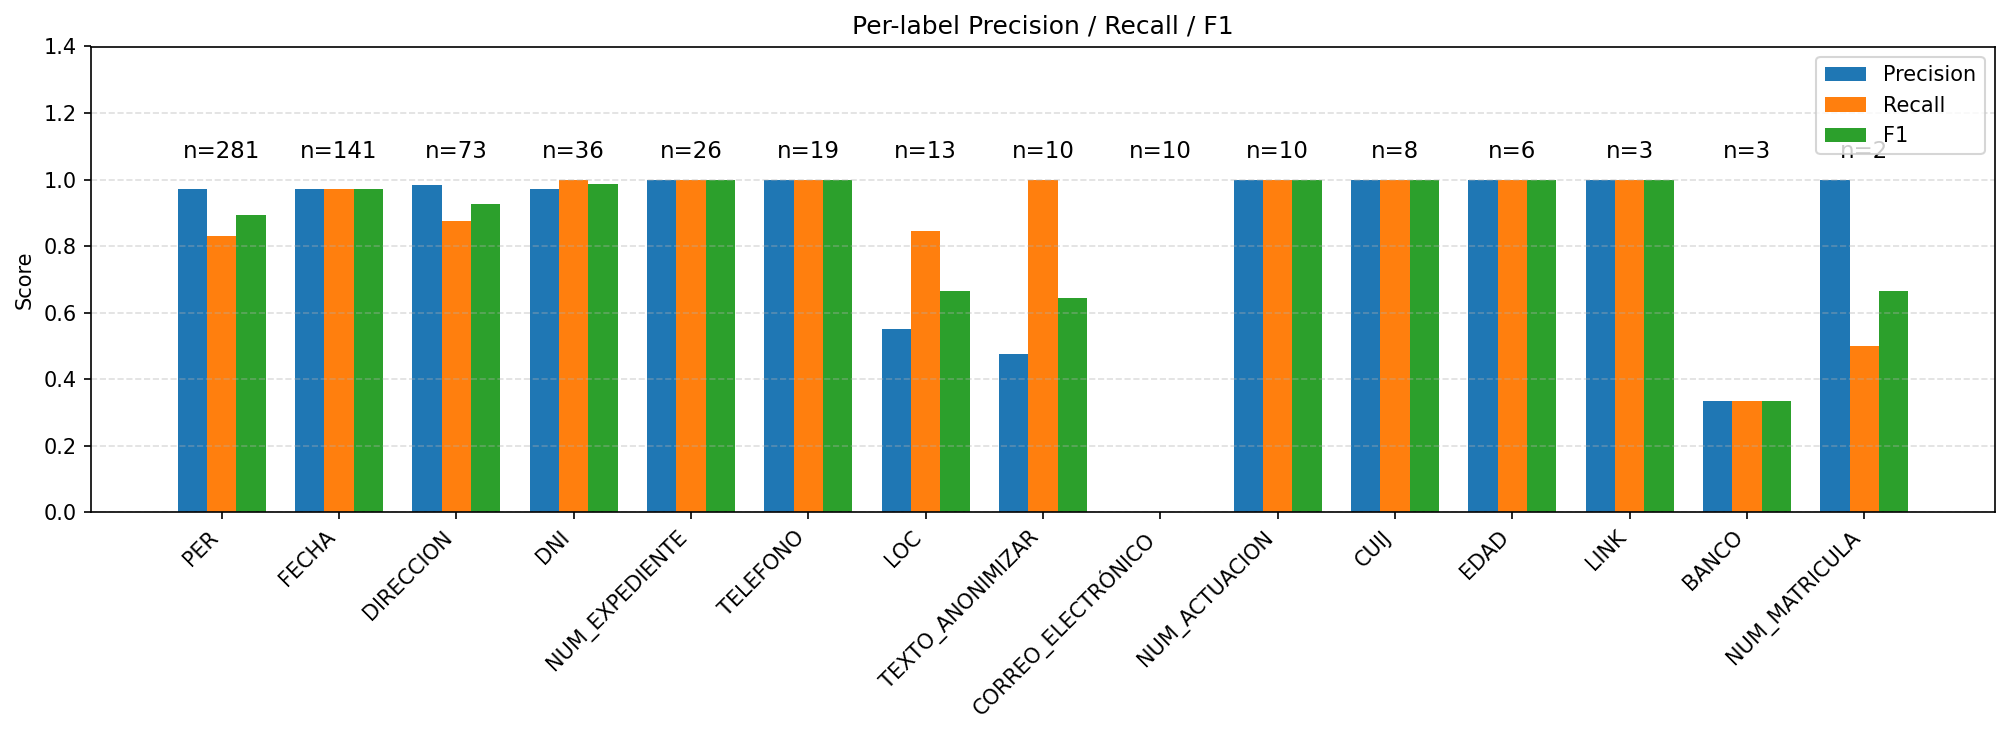

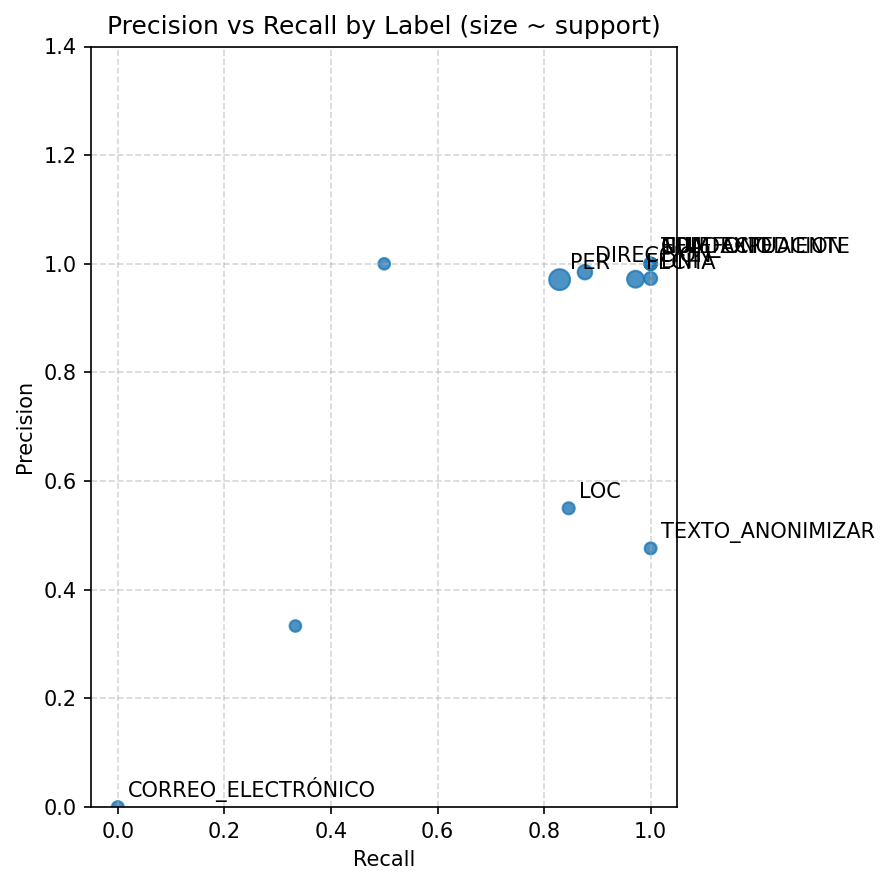

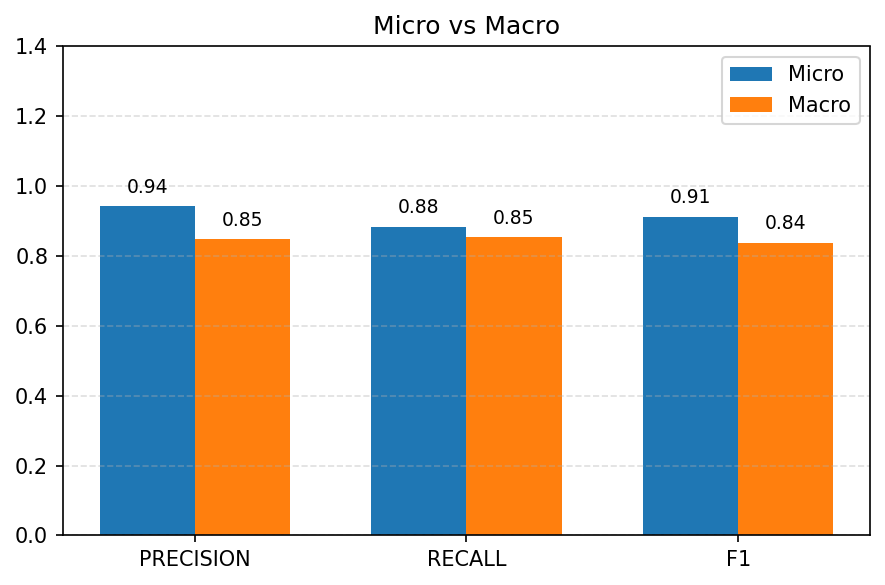

In [41]:
out = metrics_per_entity_by_span(df_main)
plot_per_label_bars(out, top=15, sort_by='support')
plot_pr_scatter(out, min_support=1, annotate_top=12)
plot_micro_macro(out)


In [26]:
out

{'per_label': {'DIRECCION': {'precision': 0.9868421052631579,
   'recall': 0.8928571428571429,
   'f1': 0.9375,
   'support': 84},
  'CORREO_ELECTRÓNICO': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'support': 12},
  'TEXTO_ANONIMIZAR': {'precision': 0.5185185185185185,
   'recall': 1.0,
   'f1': 0.6829268292682926,
   'support': 14},
  'TELEFONO': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 24},
  'NUM_EXPEDIENTE': {'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0,
   'support': 35},
  'CUIJ': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 9},
  'PER': {'precision': 0.9818181818181818,
   'recall': 0.8944099378881988,
   'f1': 0.9360780065005416,
   'support': 483},
  'NUM_ACTUACION': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 11},
  'FECHA': {'precision': 0.975609756097561,
   'recall': 0.9696969696969697,
   'f1': 0.9726443768996961,
   'support': 165},
  'DNI': {'precision': 0.9850746268656716,
   'recall': 1.0,
   'f1': 0.992481203007518

In [457]:
print(df.text.apply(lambda x: '\n'.join(x.split(' '))).iloc[0])
# medir cantidades de recall, f1, y precision por cada label

JUZGADO
DE
1RA
INSTANCIA
EN
LO
PENAL
CONTRAVENCIONAL
Y
DE
FALTAS
N°10
SECRETARIA
N°19


In [ ]:
norm(val.get('attrs', {}).get('aymurai_alt_text', None) if val else None)

'IPP 108848/2024-0'

In [ ]:
metrics_for_label(df, target='label')

{'PER'} set()
{'PER'} {'PER'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'CUIJ'} {'CUIJ'}
{'PER'} set()
{'PER'} set()
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'CUIJ'} {'CUIJ'}
{'PER'} {'PER'}
{'NUM_ACTUACION'} {'NUM_ACTUACION'}
{'FECHA'} {'FECHA'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
set() {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'NUM_EXPEDIENTE'} {'NUM_EXPEDIENTE'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'FECHA'} {'FECHA'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
set() {'PER'}
{'DIRECCION'} {'DIRECCION'}
{'DIRECCION'} {'DIRECCION'}
{'PER'} {'PER'}
{'PER'} {'PER'}
set() {'PER'}
set() {'PER'}
{'FECHA'} {'FECHA'}
{'PER'} {'PER'}
{'PER'} {'PER'}
{'DIRECC

{'recall': 0.9315789473684211,
 'precision': 0.9779005524861878,
 'f1': 0.954177897574124}

In [ ]:
for i in range():
    try:
        val = eval(df.validation.iloc[i])[0]
    except:
        val = []
    try:
        pred = eval(df.prediction.iloc[i])[0]
    except:
        pred = []

    text_val  = val.get('attrs', {}).get('aymurai_alt_text', None) if val else None
    text_pred = pred.get('attrs', {}).get('aymurai_alt_text', None) if pred else None
    label_pred = pred.get('label', None) if pred else None
    label_val  = val.get('attrs', {}).get('aymurai_label', None) if val else None

    #if text_val != None and label_val != None and text_pred != None and label_pred != None:
    if text_val != text_pred or label_val != label_pred: 
        print('text_val: ',text_val, 'label_val: ', label_val)
        print('text_pred: ',text_pred, 'label_pred: ', label_pred)
        print('\n')


text_val:  None label_val:  FECHA
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  FECHA
text_pred:  None label_pred:  None


text_val:  GOMEZ label_val:  PER
text_pred:  25 DE FEBRERO DE 2022 label_pred:  FECHA


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  10 de junio del 2022 label_val:  FECHA
text_pred:  LA_DENUNCIANTE label_pred:  PER


text_val:  None label_val:  PER
text_pred:  None label_pred:  None


text_val:  None label_val:  None
text_pred:  se label_pred:  PER


text_val:  None label_val:  None
text_pred:  Arévalo, M